# Coupled 2-species reaction–diffusion in d=1 — a multi-field spatial theory

**Showcases:** coupled 2-species spatial reaction–diffusion; matrix reaction coupling → a **cross-correlator** $C_{ab}$ alongside the auto-correlator $C_{aa}$. The two fields $a,b$ are tied by an off-diagonal $(+g,-h)$ reaction matrix — a damped predator–prey loop at every wavenumber — so the pipeline solves them on the **coupled spectral path**: every diagram becomes a weighted sum of scalar chamber integrals over per-segment spectral assignments. Run here to **1-loop** (tree + the cubic-vertex correction).

$$\partial_t a = D\,\partial_x^2 a - \mu_a a - g\,b - g_a a^3 + \eta_a,\qquad \partial_t b = D\,\partial_x^2 b - \mu_b b + h\,a - g_b b^3 + \eta_b,$$
$$\langle\eta_i(x,t)\,\eta_j(x',t')\rangle = 2T_i\,\delta_{ij}\,\delta(x-x')\,\delta(t-t').$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file — two **physical fields** `a`, `b` (response legs `da`, `db`), the matrix reaction coupling, the cubic vertices, and the white-noise amplitudes.

In [2]:
model, mod = dd.load_theory('coupled_rd_2species_1d')
dd.describe_model(model, mod)
fp = dd.parameters_from_model(model)   # parameters baked into the theory
eig = np.linalg.eigvals([[fp['mua'], fp['g']], [-fp['h'], fp['mub']]])
print('\nreaction-matrix eigenvalues:', np.round(eig, 4),
      ' (complex pair -> damped oscillation -> tau-asymmetric C_ab)')

────────────────────────────────────────────────────────────────────────
  coupled-rd-2species-1d
────────────────────────────────────────────────────────────────────────
Domain         : spatial PDE · d=1 · boundary=infinite · initial=stationary
Fields         : a (x∈ℝ^1); b (x∈ℝ^1)
Response fields: at, bt
Parameters     :
    mua = 1.5  (positive)
    mub = 1.2  (positive)
    Da = 0.8  (positive)
    Db = 0.8  (positive)
    g = 0.4
    h = 0.3
    ga = 0.3
    gb = 0.3
    Ta = 1.0  (positive)
    Tb = 0.7  (positive)
Mean-field saddle (solved by the pipeline): astar, bstar
Suggested run  : k=2, max_ell=1

Coupled 2-species reaction-diffusion in d=1 (the spatial multi-field
demo theory).

Two diffusing species ``a(x,t)``, ``b(x,t)`` with a matrix reaction
coupling (an off-diagonal predator-prey pair → a complex eigenvalue pair
→ damped spatio-temporal oscillation) and stabilizing cubic
nonlinearities, driven by independent white noise:

    da/dt = -mua*a - g*b  + Da ∇²a - ga*a³ + 

## 2. The pipeline → theoretical cumulants

One `dd.run` **per leg pair**, on a shared equal-time $x$ grid: `external_fields=[('da',1),('da',1)]` gives the auto-correlator $C_{aa}(x)$, and `[('da',1),('db',1)]` gives the cross-correlator $C_{ab}(x)$. Each is run to tree + 1-loop. The cross-correlator is small but nonzero — it exists *only* because the reaction matrix couples the two species.

C_aa(0) = +0.39409   (8 live diagrams, 2.5s)


C_ab(0) = -0.00163   (16 live diagrams, 1.6s)


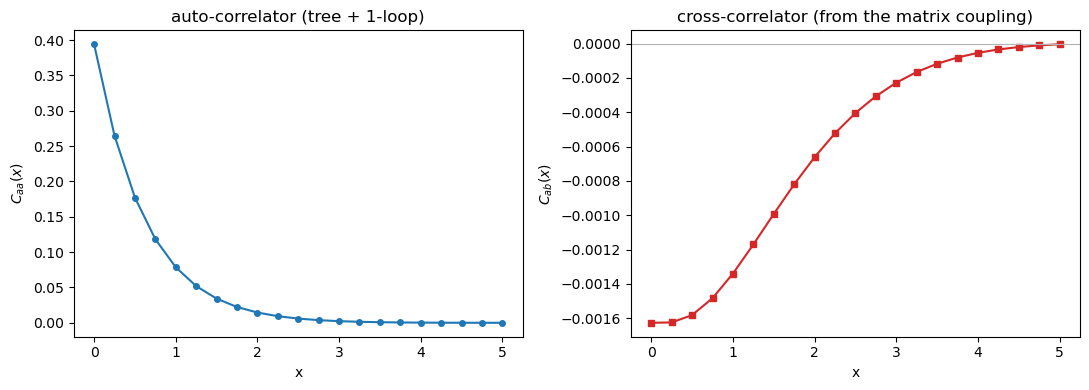

In [3]:
import dataclasses
xs = np.linspace(0.0, 5.0, 21)               # equal-time separations x >= 0
base = dd.Config(k=2, max_ell=1, spatial_grid=xs,  # tree + 1-loop, C(x) at tau=0
                 parameters={'mua': 1.5, 'mub': 1.2, 'Da': 0.8, 'Db': 0.8, 'g': 0.4, 'h': 0.3,
                             'ga': 0.3, 'gb': 0.3, 'Ta': 1.0, 'Tb': 0.7},
                 tau_max=0.0, tau_step=1.0)
LEGS = {'aa': [('da', 1), ('da', 1)],        # auto-correlator <a a>
        'ab': [('da', 1), ('db', 1)]}        # cross-correlator <a b>

C = {}                                        # C[pair] -> (n_x,) equal-time curve
for pair, legs in LEGS.items():
    t0 = time.time()
    res = dd.run(model, dataclasses.replace(base, external_fields=legs), mod)
    mid = res['C_tau_x'].shape[0] // 2        # tau = 0 row
    C[pair] = np.real(res['C_tau_x'])[mid]
    print('C_%s(0) = %+.5f   (%.0f live diagrams, %.1fs)'
          % (pair, C[pair][0],
             (res.get('spatial_info') or {}).get('n_live_diagrams', 0),
             time.time() - t0))
xs_th = res['spatial_grid']

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(xs_th, C['aa'], '-o', ms=4, color='C0')
ax[0].set_xlabel('x'); ax[0].set_ylabel(r'$C_{aa}(x)$')
ax[0].set_title('auto-correlator (tree + 1-loop)')
ax[1].plot(xs_th, C['ab'], '-s', ms=4, color='C3')
ax[1].axhline(0, color='0.7', lw=0.8)
ax[1].set_xlabel('x'); ax[1].set_ylabel(r'$C_{ab}(x)$')
ax[1].set_title('cross-correlator (from the matrix coupling)')
plt.tight_layout(); plt.show()

# ── more dd.Config knobs you can add (commented; `dd.config_options()` prints all) ──
#   max_ell=2,                      # loop order: 0=tree · 1=+1-loop · 2=+2-loop
#   output='moment',                # 'cumulant' (default) | 'moment' | 'central_moment'
#   show_orders='incremental',      # 'cumulative' (default) | 'incremental' | 'total'
#   logy=True, save='fig.png',
#   parallel=True, n_workers=4,     # spatial threads (smart-gated to loop-order ≥ 2)
# The x and τ grids — do the FULL grid, or a SLICE (fix the other axis):
#   spatial_grid=(0.0, 10.0, 30),   # x axis: (lo,hi,n) or array; a single [x0] fixes x
#   tau_grid=(-4.0, 4.0, 9),        # τ axis: array | (lo,hi,n)   (or tau_max=…, tau_step=…)
#     #  full (x,τ) grid  : ranged spatial_grid + ranged tau_grid
#     #  equal-time C(x,0): tau_grid=[0.0]
#     #  fixed-x  C(x0,τ) : spatial_grid=[x0], ranged tau_grid
#   spatial_points=…,               # k≥3: (n_pts, k−1, 2) of explicit (x_j, τ_j) events
#   dyson_order=2, reference_diffusion=1.0,  # coupled unequal-D Dyson dressing

## 3. Independent simulation

A direct integration of the coupled SPDE (semi-implicit Crank–Nicolson Euler–Maruyama on a periodic ring, FFT cross-correlation estimator, replica error bars) — no reference to the diagrammatics. The reaction matrix `Mmat` and noise matrix `Nnoise` are built from the **same theory parameters** (`fp`), so the overlay is a genuine validation. We take the $x\ge 0$ half of the periodic correlator and overlay both components on the theory curves.

sim done (12s):  C_aa(0) = 0.4062 +- 0.0017   C_ab(0) = -0.0017 +- 0.0015
theory (tree+1-loop):  C_aa(0) = 0.3941   C_ab(0) = -0.0016


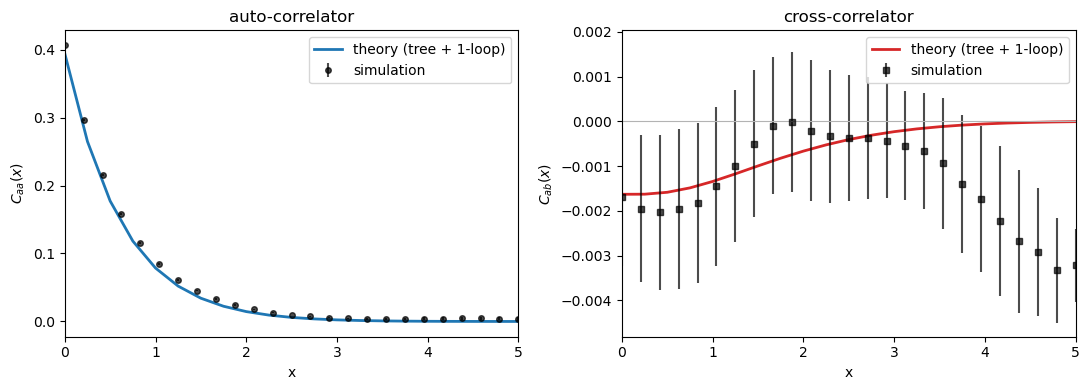

In [4]:
from models.coupled_rd_1d_sim import simulate_coupled_rd_1d

# Reaction matrix / noise matrix from the SAME theory parameters (fp).
# action convention: +g*b in the a-eqn, -h*a in the b-eqn;  <xi xi> = 2T.
Mmat   = np.array([[fp['mua'], fp['g']], [-fp['h'], fp['mub']]])
Nnoise = np.diag([2 * fp['Ta'], 2 * fp['Tb']])

# int()/float() guard: under the Sage kernel numeric params are ring types.
t0 = time.time()
sim = simulate_coupled_rd_1d(
    Mmat, float(fp['Da']), Nnoise, g=(float(fp['ga']), float(fp['gb'])),
    L=20.0, n_x=int(96), dt=2e-3, t_burn=25.0, t_run=300.0,
    n_rep=int(4), seed=int(2), lags=(0.0,))
half   = len(sim['x_grid']) // 2 + 1          # x >= 0 half of the ring
xs_sim = sim['x_grid'][:half]
C_aa_s, E_aa_s = sim['C'][0, 0, 0, :half], sim['C_err'][0, 0, 0, :half]
C_ab_s, E_ab_s = sim['C'][0, 0, 1, :half], sim['C_err'][0, 0, 1, :half]
print('sim done (%.0fs):  C_aa(0) = %.4f +- %.4f   C_ab(0) = %+.4f +- %.4f'
      % (time.time() - t0, C_aa_s[0], E_aa_s[0], C_ab_s[0], E_ab_s[0]))
print('theory (tree+1-loop):  C_aa(0) = %.4f   C_ab(0) = %+.4f'
      % (C['aa'][0], C['ab'][0]))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(xs_th, C['aa'], '-', lw=2, color='C0', label='theory (tree + 1-loop)')
ax[0].errorbar(xs_sim, C_aa_s, yerr=E_aa_s, fmt='o', ms=4, color='k',
               alpha=0.7, label='simulation')
ax[0].set_xlim(0, xs_th.max()); ax[0].set_xlabel('x')
ax[0].set_ylabel(r'$C_{aa}(x)$'); ax[0].set_title('auto-correlator')
ax[0].legend()
ax[1].plot(xs_th, C['ab'], '-', lw=2, color='C3', label='theory (tree + 1-loop)')
ax[1].errorbar(xs_sim, C_ab_s, yerr=E_ab_s, fmt='s', ms=4, color='k',
               alpha=0.7, label='simulation')
ax[1].axhline(0, color='0.7', lw=0.8)
ax[1].set_xlim(0, xs_th.max()); ax[1].set_xlabel('x')
ax[1].set_ylabel(r'$C_{ab}(x)$'); ax[1].set_title('cross-correlator')
ax[1].legend()
plt.tight_layout(); plt.show()

## Summary

The coupled tree (matrix Lyapunov correlator, analytic spectral IFT) and the 1-loop spectral-assignment correction both track the independent SPDE simulation — for the auto-correlator $C_{aa}$ *and* the much smaller, genuinely off-diagonal cross-correlator $C_{ab}$ that the matrix coupling generates. This is the spatial pipeline's **multi-field** mode: one `dd.run` per leg pair, every coupled diagram reduced to a sum of scalar chamber integrals.